# 01.7 — Matplotlib

**Phase:** 01 — Python Foundations

**Status:** VERIFIED

---

## 1. What Are We Solving?

Numbers in a table are hard to interpret. **Visualization** turns data into insight. **Matplotlib** is Python's foundational plotting library.

## 2. Why Does This Matter?

Exploratory Data Analysis (EDA) is mostly visualization. Understanding your data before modeling is critical, and Matplotlib (plus seaborn on top) is the standard tool.

## 3. Prerequisites

- Unit 01.5 (NumPy)
- Unit 01.6 (Pandas)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Create line plots, scatter plots, bar charts, and histograms
- Customize plots (labels, titles, legends, colors)
- Create subplots
- Save figures
- Use the object-oriented vs pyplot interface

## 5. Mental Model

Matplotlib has two interfaces:
- **pyplot** (`plt`) — quick, MATLAB-style, good for simple plots.
- **Object-oriented** — explicit `Figure` and `Axes` objects, good for complex/multi-panel plots.

Think of a **Figure** as the canvas and an **Axes** as a single plot on that canvas.

## 6. Line Plot

Line plots show trends over a continuous axis.

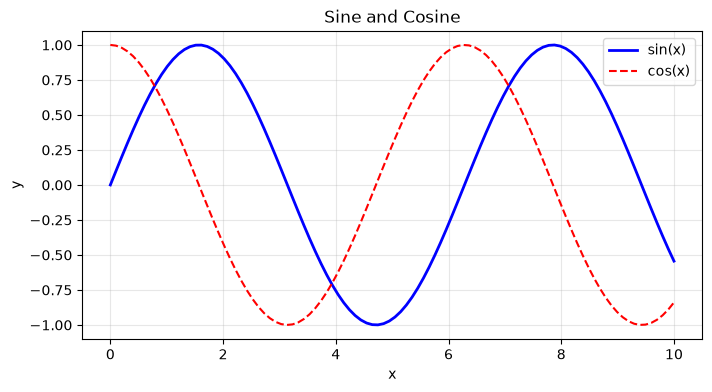

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Line plot
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label="sin(x)", color="blue", linewidth=2)
plt.plot(x, np.cos(x), label="cos(x)", color="red", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sine and Cosine")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Scatter Plot

Scatter plots show the relationship between two variables.

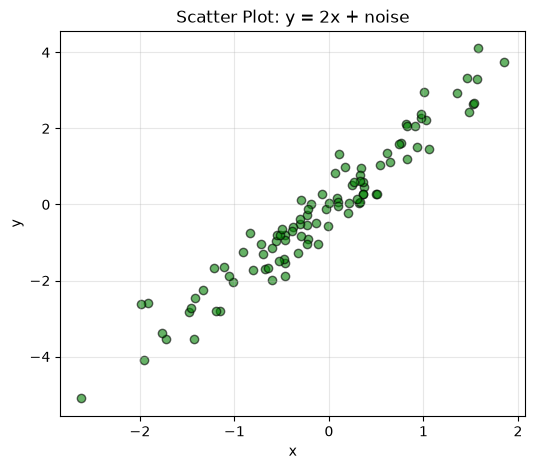

In [2]:
# Scatter plot
np.random.seed(42)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5

plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.6, color="green", edgecolor="black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot: y = 2x + noise")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Bar Chart

Bar charts compare categories.

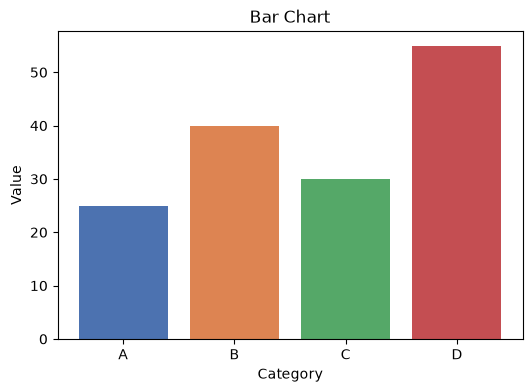

In [3]:
# Bar chart
categories = ["A", "B", "C", "D"]
values = [25, 40, 30, 55]

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.xlabel("Category")
plt.ylabel("Value")
plt.title("Bar Chart")
plt.show()

## 9. Histogram

Histograms show the distribution of a single variable.

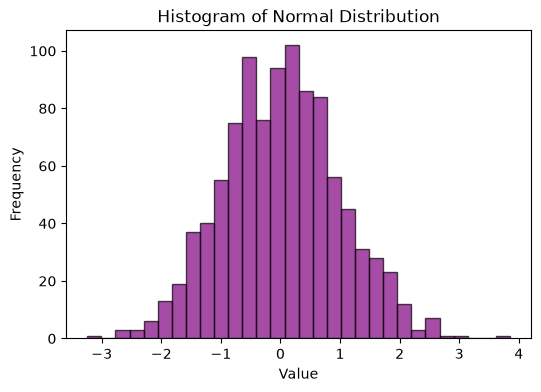

In [4]:
# Histogram
np.random.seed(42)
data = np.random.randn(1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, color="purple", alpha=0.7, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Normal Distribution")
plt.show()

## 10. Box Plot

Box plots summarize a distribution (median, quartiles, outliers).

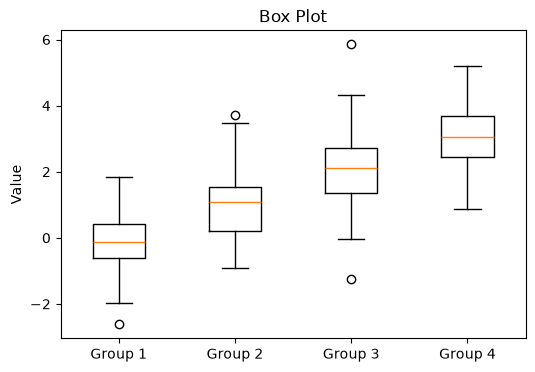

In [5]:
# Box plot
np.random.seed(42)
data = [np.random.randn(100) + i for i in range(4)]

plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=["Group 1", "Group 2", "Group 3", "Group 4"])
plt.ylabel("Value")
plt.title("Box Plot")
plt.show()

## 11. Subplots

Subplots let you place multiple plots in one figure.

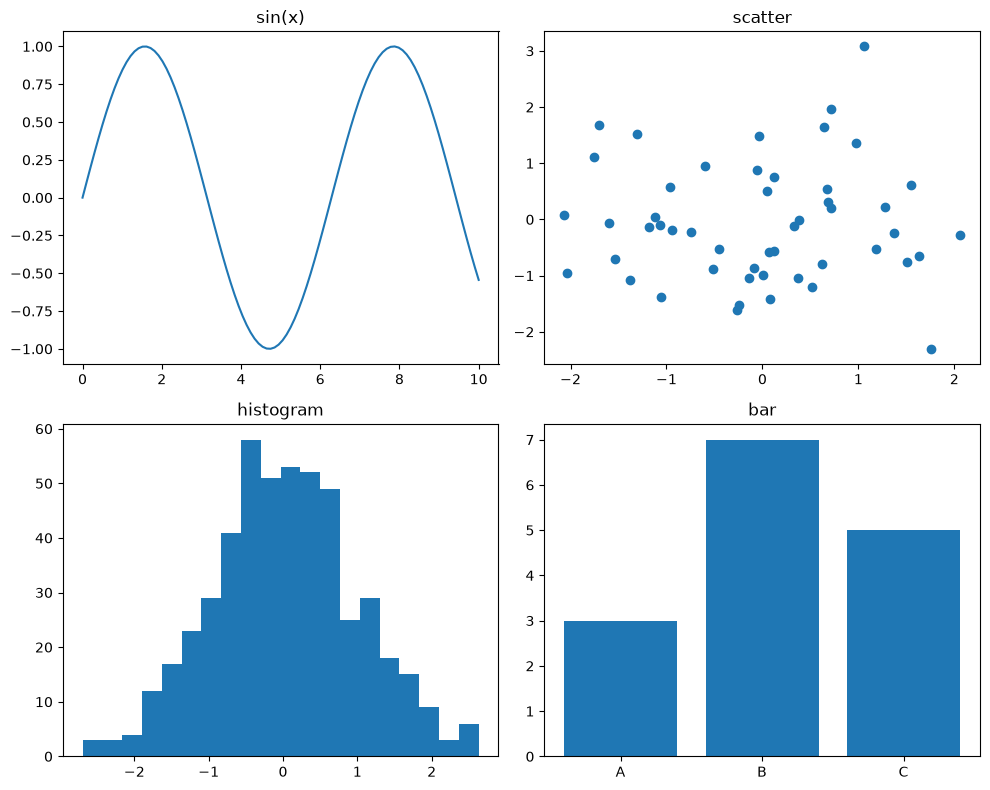

In [6]:
# Subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

x = np.linspace(0, 10, 100)

# Top-left: line
axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title("sin(x)")

# Top-right: scatter
axes[0, 1].scatter(np.random.randn(50), np.random.randn(50))
axes[0, 1].set_title("scatter")

# Bottom-left: histogram
axes[1, 0].hist(np.random.randn(500), bins=20)
axes[1, 0].set_title("histogram")

# Bottom-right: bar
axes[1, 1].bar(["A", "B", "C"], [3, 7, 5])
axes[1, 1].set_title("bar")

plt.tight_layout()
plt.show()

## 12. Object-Oriented Interface

The OO interface gives more control. This is the recommended style for complex plots.

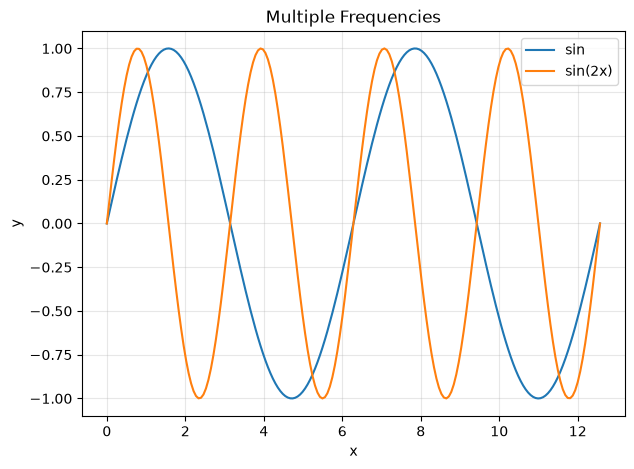

In [7]:
# Object-oriented interface
fig, ax = plt.subplots(figsize=(7, 5))

x = np.linspace(0, 4 * np.pi, 200)
ax.plot(x, np.sin(x), label="sin")
ax.plot(x, np.sin(2 * x), label="sin(2x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Multiple Frequencies")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

## 13. Saving Figures

Save plots to files for reports and presentations.

In [8]:
# Save a figure
import os

fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(0, 10, 100)
ax.plot(x, x**2, label="x^2")
ax.set_title("Saved Plot")
ax.legend()

# Save to a temp location
save_path = os.path.join(os.getcwd(), "temp_plot.png")
fig.savefig(save_path, dpi=100, bbox_inches="tight")
print(f"Saved to {save_path}")
print(f"File exists: {os.path.exists(save_path)}")

# Clean up
if os.path.exists(save_path):
    os.remove(save_path)
    print("Cleaned up temp plot.")
plt.close(fig)

Saved to D:\CODE\complete ml\notebooks\01_python\temp_plot.png
File exists: True
Cleaned up temp plot.


## 14. Experiment: Visualizing a Dataset

Let's visualize a small dataset to understand it.

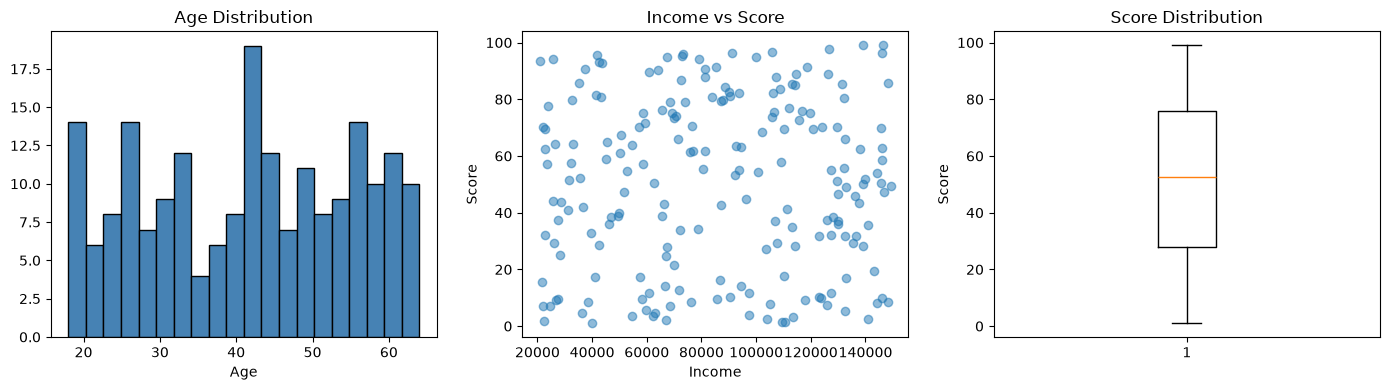

In [9]:
# Experiment: visualize a dataset
import pandas as pd

np.random.seed(42)
df = pd.DataFrame({
    "age": np.random.randint(18, 65, 200),
    "income": np.random.randint(20000, 150000, 200),
    "score": np.random.uniform(0, 100, 200),
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram of age
axes[0].hist(df["age"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Scatter of income vs score
axes[1].scatter(df["income"], df["score"], alpha=0.5)
axes[1].set_title("Income vs Score")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Score")

# Box plot of score
axes[2].boxplot(df["score"])
axes[2].set_title("Score Distribution")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

## 15. Failure Case: Plot Not Showing

A common issue is a plot not appearing. In Jupyter, use `%matplotlib inline` (default) or call `plt.show()`.

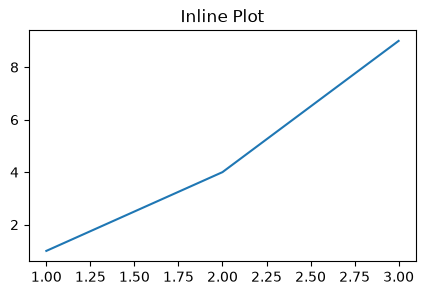

Plot displayed above.


In [10]:
# Ensure inline backend for Jupyter
%matplotlib inline

# A simple plot that should display
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Inline Plot")
plt.show()
print("Plot displayed above.")

## 16. Debugging: Common Errors

### Plot not showing
Call `plt.show()` or use `%matplotlib inline`.

### Overlapping labels
Use `plt.tight_layout()`.

### Empty plot
Check that you called `plt.plot()` before `plt.show()`.

### Wrong axes
In subplots, make sure you're plotting on the correct `axes[i, j]`.

## 17. Real-World Considerations

- **Colorblind-safe palettes**: use `seaborn` or `viridis` colormaps.
- **Labels always**: every plot needs axis labels and a title.
- **Figure size**: use `figsize` for readability.
- **DPI**: use `dpi=100+` for crisp saved figures.
- **Seaborn**: built on Matplotlib, adds statistical plots and nicer defaults.

## 18. Common Mistakes

- Forgetting axis labels and titles
- Overcrowding a plot with too much data
- Using the wrong plot type for the data
- Not calling `plt.show()`
- Mixing pyplot and OO interfaces confusingly

## 19. When NOT to Use

- Don't use Matplotlib for interactive web plots — use Plotly.
- Don't use Matplotlib for statistical plots — use seaborn.
- Don't use Matplotlib for huge datasets — use downsampling or Plotly.

## 20. Challenge

Create a 2×1 subplot: top shows a line plot of `x^3`, bottom shows a histogram of 500 random normal values.

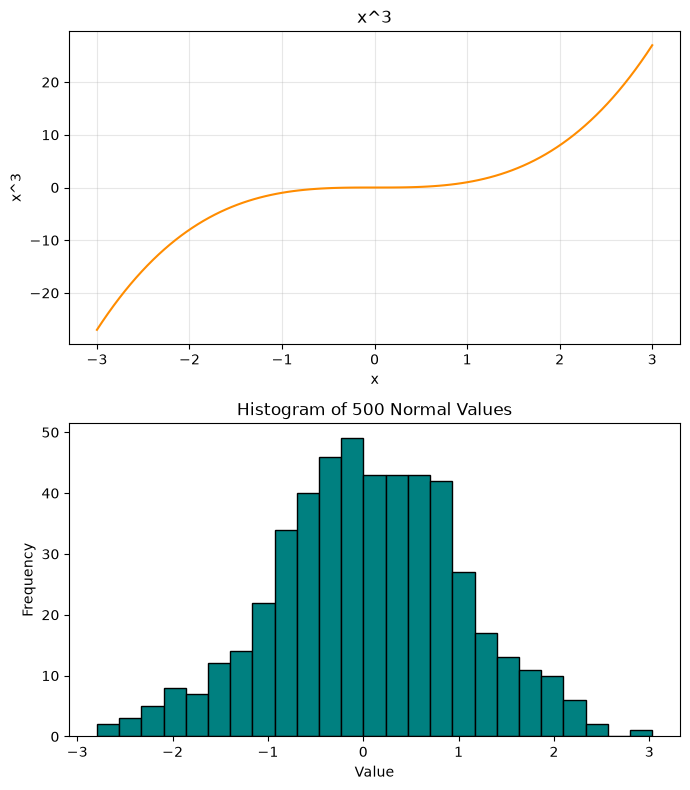

In [11]:
# Challenge: 2x1 subplot
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

x = np.linspace(-3, 3, 100)
axes[0].plot(x, x**3, color="darkorange")
axes[0].set_title("x^3")
axes[0].set_xlabel("x")
axes[0].set_ylabel("x^3")
axes[0].grid(True, alpha=0.3)

np.random.seed(1)
axes[1].hist(np.random.randn(500), bins=25, color="teal", edgecolor="black")
axes[1].set_title("Histogram of 500 Normal Values")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Hands-On Practice

### Level 1: Basic
- Create a line plot of a simple function
- Add title, axis labels, and legend

### Level 2: Guided
- Create a figure with 2 subplots side by side
- Plot a histogram of random data with 20 bins

### Level 3: Independent
- Visualize a pandas DataFrame with multiple line plots
- Create a scatter plot colored by category

### Level 4: Realistic
- Create a 2x2 subplot grid showing different plot types for one dataset

### Level 5: Challenge
- Reproduce a publication-quality figure from a paper


## Knowledge Check

1. What is the difference between `plt.plot()` and `ax.plot()`?
2. When would you use `plt.subplots()` vs `plt.figure()`?
3. How do you save a figure at high resolution for print?



## Exit Criteria

- [ ] Can create line, scatter, histogram, and bar plots
- [ ] Can use subplots to organize multiple plots
- [ ] Can customize titles, labels, legends, and colors
- [ ] Can save figures to files
- [ ] Completed Level 3+ practice



## Next Step

-> Unit 01.8: File I/O and Error Handling — reading/writing files robustly.


## 21. Closed-Book Recall

Without looking back:

1. How do you create a line plot?
2. What's the difference between `plt.plot` and `plt.scatter`?
3. How do you create subplots?
4. How do you save a figure?
5. What's the difference between pyplot and OO interfaces?

## 22. Teach-Back Questions

Explain to another person:

- When would you use a histogram vs a box plot?
- What is a scatter plot good for?
- Why is visualization important in ML?

## 23. Summary

You now understand Matplotlib's core plot types, customization, subplots, and saving. This is essential for EDA and communicating results.

## 24. Further Experiment

- Use seaborn's `sns.histplot` and `sns.scatterplot`.
- Create a heatmap with `plt.imshow`.
- Add annotations to a plot with `plt.annotate`.

## 25. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: matplotlib, numpy, pandas
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```